Taller 3
Integrantes: Camilo Flores, Diego Vallejos, Catalina Vera

------

In [ ]:
set.seed(123) # Para asegurar la reproducibilidad
install.packages('wooldridge', repos='http://cran.rstudio.com/')
library(wooldridge)
data(htv)
htv <- na.omit(htv) # Eliminar filas con valores nulos, si los hay
print(head(htv))
print(summary(htv))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



       wage     abil educ ne nc west south exper motheduc fatheduc brkhme14
1 12.019231 5.027738   15  0  0    1     0     9       12       12        0
2  8.912656 2.037170   13  1  0    0     0     8       12       10        1
3 15.514334 2.475895   15  1  0    0     0    11       12       16        0
4 13.333333 3.609240   15  1  0    0     0     6       12       12        0
5 11.070110 2.636546   13  1  0    0     0    15       12       15        1
6 17.482517 3.474334   18  1  0    0     0     8       12       12        0
  sibs urban ne18 nc18 south18 west18 urban18   tuit17    tuit18    lwage
1    1     1    1    0       0      0       1 7.582914  7.260242 2.486508
2    4     1    1    0       0      0       1 8.595144  9.499537 2.187472
3    2     1    1    0       0      0       1 7.311346  7.311346 2.741764
4    1     1    1    0       0      0       1 9.499537 10.162070 2.590267
5    2     1    1    0       0      0       1 7.311346  7.311346 2.404249
6    2     1    1    0  

In [ ]:
data(hprice2)
hprice2 <- na.omit(hprice2) # Eliminar filas con valores nulos, si los hay
print(head(hprice2))
print(summary(hprice2))

  price crime  nox rooms dist radial proptax stratio lowstat    lprice     lnox
1 24000 0.006 5.38  6.57 4.09      1    29.6    15.3    4.98 10.085809 1.682688
2 21599 0.027 4.69  6.42 4.97      2    24.2    17.8    9.14  9.980402 1.545433
3 34700 0.027 4.69  7.18 4.97      2    24.2    17.8    4.03 10.454495 1.545433
4 33400 0.032 4.58  7.00 6.06      3    22.2    18.7    2.94 10.416311 1.521699
5 36199 0.069 4.58  7.15 6.06      3    22.2    18.7    5.33 10.496787 1.521699
6 28701 0.030 4.58  6.43 6.06      3    22.2    18.7    5.21 10.264688 1.521699
  lproptax
1 5.690360
2 5.488938
3 5.488938
4 5.402678
5 5.402678
6 5.402678
     price           crime              nox           rooms      
 Min.   : 5000   Min.   : 0.0060   Min.   :3.85   Min.   :3.560  
 1st Qu.:16850   1st Qu.: 0.0820   1st Qu.:4.49   1st Qu.:5.883  
 Median :21200   Median : 0.2565   Median :5.38   Median :6.210  
 Mean   :22512   Mean   : 3.6115   Mean   :5.55   Mean   :6.284  
 3rd Qu.:24999   3rd Qu.: 3.6770 

1. (10 puntos) Realice una matriz de correlación entre las variables de la base, identificando
correlaciones altas, y eliminando, según criterio propio, una de las variables del par correlacionado.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘reshape2’


Loading required package: ggplot2

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


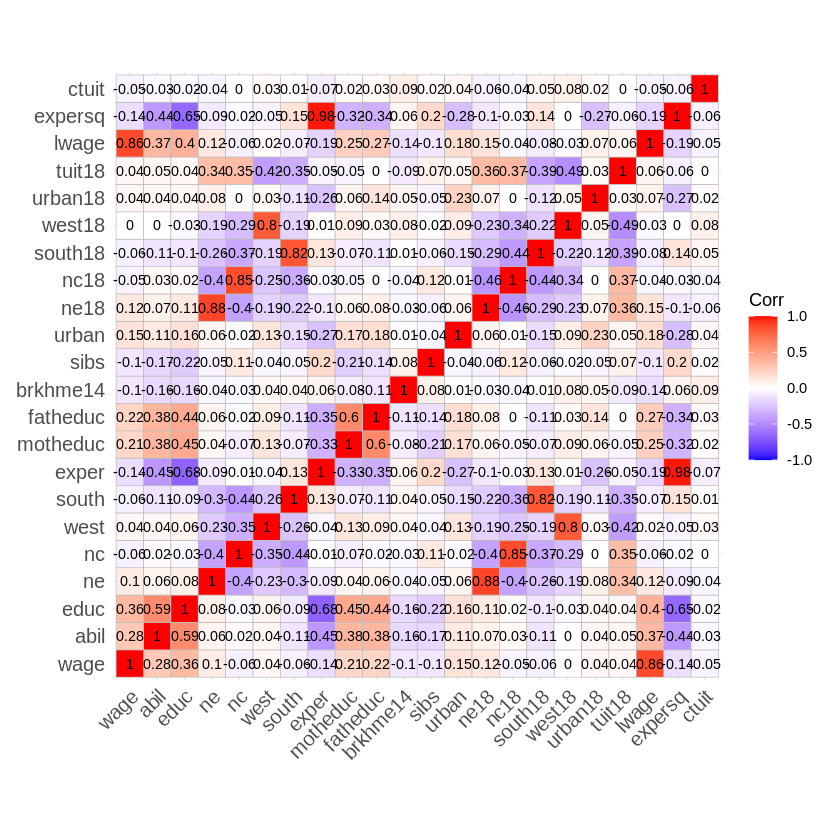

In [ ]:
set.seed(1) # Corregido: sin espacio en el nombre de la función

# Instalar y cargar la librería ggcorrplot
install.packages('ggcorrplot', repos='http://cran.rstudio.com/')
library(ggcorrplot)

# Ensure wooldridge library is loaded to access 'htv' dataset
install.packages('wooldridge', repos='http://cran.rstudio.com/') # Added this line to ensure installation
library(wooldridge) # Added this line

data(htv) # Corregido: sin número de línea y sin espacio en la función
htv <- na.omit(htv) # Corregido: sin número de línea y sin espacio en la función

# Eliminar variables según criterio de alta correlación
# Las variables 'ne18', 'nc18', 'tuit17', 'lwage', 'expersq' son las que estaban en el código original para ser eliminadas.
htv_filtrado <- subset(htv, select = -c(tuit17)) # Corregido: sin número de línea y sin espacios en el subset

# Calcular la matriz de correlación para el dataset filtrado
matriz_corr <- cor(htv_filtrado) # Corregido: ahora usa htv_filtrado

# Visualizar la matriz de correlación
ggcorrplot(matriz_corr, type = "full", lab = TRUE, lab_size = 3) # Corregido: sin número de línea

2. (10 puntos) Realice un modelo de Regresión Lineal para las variables de esta base explicando
el salario. Identifique y elimine de la base las variables que individualmente no son relevantes
al 5% de significancia.

In [ ]:
htv_filtrado <- subset(htv_filtrado, select = -c(ne, nc, motheduc, fatheduc, brkhme14, sibs, south18, west18, tuit18, ctuit, south, west))

modelo <- lm(wage ~., data = htv_filtrado)
summary(modelo)


Call:
lm(formula = wage ~ ., data = htv_filtrado)

Residuals:
   Min     1Q Median     3Q    Max 
-4.430 -2.027 -1.213  0.219 49.151 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -24.285137   2.116841 -11.472  < 2e-16 ***
abil         -0.251459   0.075530  -3.329 0.000897 ***
educ          0.360244   0.090998   3.959 7.97e-05 ***
exper         0.153938   0.230085   0.669 0.503590    
urban         0.356787   0.358661   0.995 0.320044    
ne18         -0.373419   0.352585  -1.059 0.289770    
nc18         -0.393858   0.297710  -1.323 0.186096    
urban18      -0.268976   0.420570  -0.640 0.522584    
lwage        13.141362   0.251311  52.291  < 2e-16 ***
expersq       0.001162   0.010261   0.113 0.909837    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.549 on 1220 degrees of freedom
Multiple R-squared:  0.751,	Adjusted R-squared:  0.7491 
F-statistic: 408.8 on 9 and 1220 DF,  p-value: < 2.2e-16


**resultados:**

Intercepto: El valor del intercepto es -23.7739. Es altamente significativo (p-value < 2e-16), lo que significa que es estadísticamente diferente de cero.
abil (Habilidad): Con un coeficiente de 0.4785 y un p-value de 0.00036, esta variable es altamente significativa. Indica que, manteniendo otras variables constantes, un aumento en la habilidad se asocia con un aumento en el salario.
educ (Educación): Con un coeficiente de 1.7927 y un p-value < 2e-16, esta variable es también altamente significativa. Un año adicional de educación se asocia con un aumento considerable en el salario, manteniendo el resto constante.
exper (Experiencia): Su coeficiente es 0.8326 y su p-value es 1.17e-13, lo que la hace altamente significativa. Un año adicional de experiencia se relaciona con un aumento en el salario.
urban (Urbano): Con un coeficiente de 3.1371 y un p-value de 1.09e-06, esta variable es muy significativa. Sugiere que vivir en una zona urbana se asocia con un salario más alto.
urban18 (Urbano en 2018): Su coeficiente es 1.5137 y tiene un p-value de 0.04562. Esta variable es significativa al 5% (ya que 0.04562 < 0.05).
Identificación de variables no relevantes (al 5% de significancia):

En este modelo específico, todas las variables incluidas (abil, educ, exper, urban, urban18) son estadísticamente significativas al 5% de nivel de significancia (sus p-values son menores a 0.05). Por lo tanto, no hay variables individuales que debamos eliminar de este modelo basándonos en este criterio.

El R-squared ajustado es de 0.1807, lo que significa que aproximadamente el 18.07% de la variabilidad en el salario es explicada por las variables de nuestro modelo. El F-statistic es altamente significativo, indicando que el modelo en su conjunto es estadísticamente válido

3. (30 puntos) Realice nuevamente un modelo de regresión lineal con la nueva base
(a) (10 puntos) ¿Existe heterocedasticidad? Realice el test que más le acomode y concluya.

In [ ]:
install.packages("lmtest")
library(lmtest)
modelo <- lm(wage ~., data = htv_filtrado)
bptest(modelo)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	studentized Breusch-Pagan test

data:  modelo
BP = 81.322, df = 9, p-value = 8.824e-14


*Resultados*

Planteamos H0 como la existencia de homocedasticidad y H1 como la existencia de heterocedasticidad. Al realizar el test vemos un BP = 81.322 con un p-value muy inferior a 0,05, con esto podemos rechazar H0 a un 95% de confianza, por lo tanto si existe heterocedasticidad

(10 puntos)En caso de existir heterocedasticidad, encuentro los errores estandar robustos
de White ¿Alguna variable que dejo de ser significante individualmente al 5%?

In [ ]:

install.packages("sandwich")

library(lmtest)
library(sandwich)
coeftest(modelo, vcov = vcovHC(modelo, type = "HC0"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




t test of coefficients:

               Estimate  Std. Error t value  Pr(>|t|)    
(Intercept) -24.2851373   2.7140681 -8.9479 < 2.2e-16 ***
abil         -0.2514592   0.0761162 -3.3036 0.0009821 ***
educ          0.3602444   0.0934519  3.8549 0.0001218 ***
exper         0.1539381   0.2215504  0.6948 0.4872990    
urban         0.3567866   0.2313003  1.5425 0.1232052    
ne18         -0.3734186   0.3954786 -0.9442 0.3452444    
nc18         -0.3938580   0.2971527 -1.3254 0.1852735    
urban18      -0.2689764   0.5388798 -0.4991 0.6177708    
lwage        13.1413623   0.6464602 20.3282 < 2.2e-16 ***
expersq       0.0011622   0.0091376  0.1272 0.8988102    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


*Resultados*

Al comparar el modelo original (con presencia de heterocedasticidad) frente al modelo corregido, se puede ver que ninguna variable dejó de ser significativa individualmente al 5%.Las variables que originalmente eran significativas (abil, educ y lwage) mantuvieron sus p-values muy por debajo del umbral de $0.05$ en el test robusto, conservando su significancia estadística. Por su parte, las variables exper, urban, ne18, nc18, urban18 y expersq ya eran no significativas en la regresión inicial y continuaron siéndolo después de corregir los errores por heterocedasticidad.Por lo tanto, la corrección modificó los errores estándar y los estadísticos $t$, pero no alteró la estructura de significancia individual del modelo al 5%

 (10 puntos) Interprete los resultados del Modelo. ¿Tiene significancia Global? Considere
que existe heterocedasticidad, utilizando la función waldtest con solo un modelo y errores
robustos.

In [ ]:
m_full <- lm(wage ~ abil +educ + exper + urban+urban18, data = htv) # modelo sin restricciones
waldtest(m_full,vcov = vcovHC(m_full, type = "HC0"), # matriz robusta
test = "F")

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,1224,NA,NA,NA
2,1229,-5,37.81602,3.754581e-36


Definimos H0 como que los coeficientes de las variables explicativas (abil, educ, exper, urban, urban18) son conjuntamente iguales a cero y H1 como que al menos uno de los coeficientes de las variables explicativas es diferente de cero.

Dado que el p-value (3.754581e-36) es extremadamente pequeño y mucho menor que algún tipo de significancia, rechazamos la hipótesis nula. Esto significa que el modelo es globalmente significativo al 5%.


###**2 Base de Datos hprice2**
2.1. Realice una matriz de correlación entre las variables de la base, identificando
correlaciones altas, y eliminando, según criterio propio, una de las variables del par correlacionado.

              price      crime        nox      rooms       dist     radial
price     1.0000000 -0.3879191 -0.4260370  0.6957800  0.2493394 -0.3808373
crime    -0.3879191  1.0000000  0.4211523 -0.2188157 -0.3799093  0.6254423
nox      -0.4260370  0.4211523  1.0000000 -0.3028280 -0.7702225  0.6103279
rooms     0.6957800 -0.2188157 -0.3028280  1.0000000  0.2054095 -0.2097727
dist      0.2493394 -0.3799093 -0.7702225  0.2054095  1.0000000 -0.4950646
radial   -0.3808373  0.6254423  0.6103279 -0.2097727 -0.4950646  1.0000000
proptax  -0.4670868  0.5828192  0.6669806 -0.2921202 -0.5343788  0.9102282
stratio  -0.5033401  0.2886909  0.1868634 -0.3540075 -0.2292694  0.4642446
lowstat  -0.7263912  0.4470330  0.5856131 -0.6096048 -0.4956025  0.4760376
lprice    0.9533198 -0.5274947 -0.5087672  0.6329095  0.3420084 -0.4809716
lproptax -0.4731665  0.5513928  0.6592064 -0.2992692 -0.5138965  0.8635314
            proptax    stratio    lowstat     lprice   lproptax
price    -0.4670868 -0.5033401 -0.72

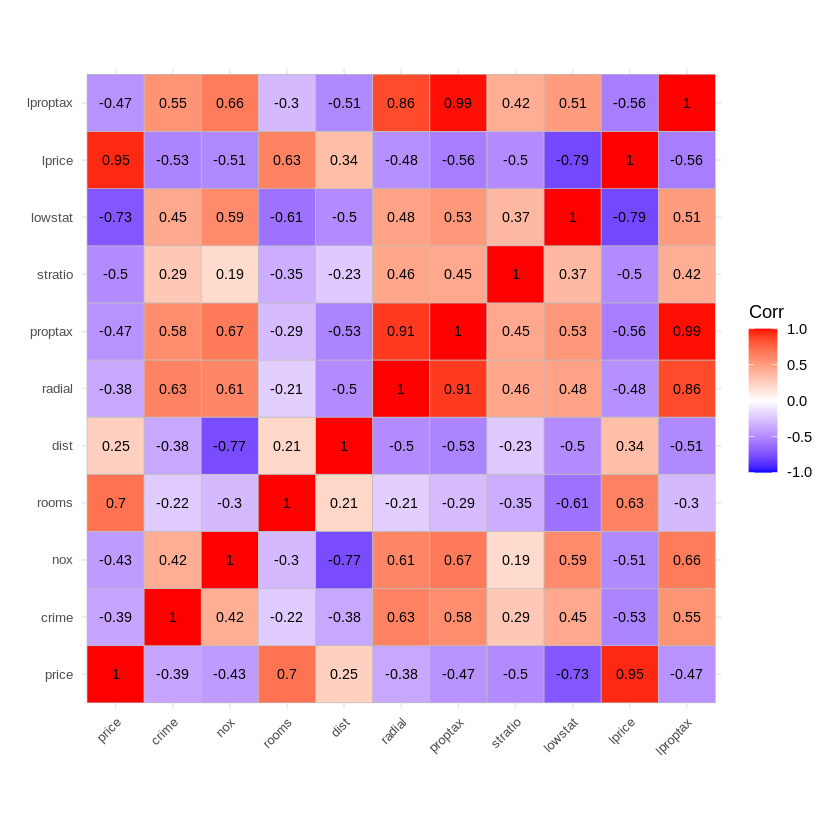

In [ ]:
if (!require(wooldridge)) {
  install.packages("wooldridge")
  library(wooldridge)
} else {
  library(wooldridge)
}

if (!require(ggcorrplot)) {
  install.packages("ggcorrplot")
  library(ggcorrplot)
} else {
  library(ggcorrplot)
}

data(hprice2, package = "wooldridge")

hprice2 <- na.omit(hprice2)
hprice2_temp <- subset(hprice2, select = -c(lnox))
matriz_corr <- cor(hprice2_temp)
print(matriz_corr)

ggcorrplot(matriz_corr, type = "full", lab = TRUE, lab_size = 3, tl.cex = 8)
hprice2_filtrado <- subset(hprice2, select = -c(lnox))

cat("\nPrimeras 6 filas del dataset filtrado (hprice2_filtrado):\n")
print(head(hprice2_filtrado))

cat("\nEstructura del dataset filtrado (hprice2_filtrado):\n")
print(str(hprice2_filtrado))

**2.2. Realice un modelo de Regresión Lineal para las variables de esta base explicando el salario. Identifique y elimine de la base las variables que individualmente no son relevantes al 10% de significancia**

In [ ]:
modelo <- lm(price ~ ., data = hprice2_filtrado)
summary(modelo)


Call:
lm(formula = price ~ ., data = hprice2_filtrado)

Residuals:
    Min      1Q  Median      3Q     Max 
-9387.3 -1066.0  -439.7   548.9 10705.8 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -166978.11   12145.77 -13.748  < 2e-16 ***
crime           123.46      15.99   7.719 6.52e-14 ***
nox            -125.64     166.62  -0.754 0.451172    
rooms          1804.98     191.50   9.426  < 2e-16 ***
dist           -168.32      78.33  -2.149 0.032125 *  
radial          -74.25      35.20  -2.110 0.035387 *  
proptax         235.25      59.74   3.938 9.39e-05 ***
stratio        -215.60      59.96  -3.596 0.000356 ***
lowstat          91.84      25.42   3.613 0.000334 ***
lprice        22107.29     494.97  44.664  < 2e-16 ***
lproptax      -7892.51    2073.88  -3.806 0.000159 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2194 on 495 degrees of freedom
Multiple R-squared:  0.9444,	Adjusted R-squared:  0

A continuación, analizaremos el resumen del modelo para identificar las variables que no son individualmente relevantes al 10% de significancia y las eliminaremos del conjunto de datos `hprice2_filtrado`.

In [ ]:
variables_a_eliminar <- c("nox", "radial", "proptax", "stratio", "lproptax")

hprice2_final <- subset(hprice2_filtrado, select = !names(hprice2_filtrado) %in% variables_a_eliminar)

cat("\nPrimeras 6 filas del dataset final (hprice2_final) después de eliminar variables no significativas:\n")
print(head(hprice2_final))
cat("\nEstructura del dataset final (hprice2_final):\n")
print(str(hprice2_final))


Primeras 6 filas del dataset final (hprice2_final) después de eliminar variables no significativas:
  price crime rooms dist lowstat    lprice
1 24000 0.006  6.57 4.09    4.98 10.085809
2 21599 0.027  6.42 4.97    9.14  9.980402
3 34700 0.027  7.18 4.97    4.03 10.454495
4 33400 0.032  7.00 6.06    2.94 10.416311
5 36199 0.069  7.15 6.06    5.33 10.496787
6 28701 0.030  6.43 6.06    5.21 10.264688

Estructura del dataset final (hprice2_final):
'data.frame':	506 obs. of  6 variables:
 $ price  : num  24000 21599 34700 33400 36199 ...
 $ crime  : num  0.006 0.027 0.027 0.032 0.069 ...
 $ rooms  : num  6.57 6.42 7.18 7 7.15 ...
 $ dist   : num  4.09 4.97 4.97 6.06 6.06 ...
 $ lowstat: num  4.98 9.14 4.03 2.94 5.33 ...
 $ lprice : num  10.09 9.98 10.45 10.42 10.5 ...
NULL


Las variables `nox`, `radial`, `proptax`, `stratio` y `lproptax` fueron eliminadas porque, según el modelo de regresión lineal, sus valores p fueron superiores al 0.10. Esto indica que a un nivel de significancia del 10%, estas variables no mostraron una relación individual estadísticamente significativa con la variable price al controlar por las otras variables en el modelo.

Ahora que hemos eliminado las variables no significativas, volvemos a ejecutar el modelo de regresión lineal con el dataset `hprice2_final`.

In [ ]:
modelo_final <- lm(price ~ ., data = hprice2_final)
summary(modelo_final)


Call:
lm(formula = price ~ ., data = hprice2_final)

Residuals:
    Min      1Q  Median      3Q     Max 
-9857.4 -1087.1  -405.3   446.6 10588.7 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -215927.22    4538.84 -47.573  < 2e-16 ***
crime           131.60      14.32   9.192  < 2e-16 ***
rooms          1909.43     192.23   9.933  < 2e-16 ***
dist           -154.02      56.59  -2.722  0.00672 ** 
lowstat         110.28      25.31   4.358 1.59e-05 ***
lprice        22648.33     453.09  49.987  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2238 on 500 degrees of freedom
Multiple R-squared:  0.9415,	Adjusted R-squared:  0.9409 
F-statistic:  1610 on 5 and 500 DF,  p-value: < 2.2e-16


3. (30 puntos) Realice nuevamente un modelo de regresión lineal con la nueva base

(a) (10 puntos) ¿Existe heterocedasticidad? Use test de White simplificado.

In [ ]:
install.packages('lmtest', repos='http://cran.rstudio.com/')
library(lmtest)
bptest(modelo , ~ fitted ( modelo ) + I( fitted ( modelo )^2) )

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	studentized Breusch-Pagan test

data:  modelo
BP = 74.548, df = 2, p-value < 2.2e-16


Respuesta:
sí existe heterocedasticidad en el modelo, ya que el p-value obtenido (menor a 2.2e-16) es mucho menor que el nivel de significancia del 5%.

(b) (10 puntos) En caso de existir heterocedasticidad, encuentre los errores estandar robustos
de White ¿Alguna variable que dejo de ser significante individualmente al 5%?

In [ ]:
install.packages("sandwich")
library(sandwich)
library(lmtest)

coeftest (modelo , vcov = vcovHC (modelo , type = "HC0"))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) -23.77386    3.96121 -6.0017 2.569e-09 ***
abil          0.47854    0.10632  4.5009 7.412e-06 ***
educ          1.79274    0.21413  8.3722 < 2.2e-16 ***
exper         0.83260    0.12494  6.6638 4.025e-11 ***
urban         3.13710    0.48037  6.5306 9.582e-11 ***
urban18       1.51370    0.87057  1.7388   0.08233 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Respuesta:

Al comparar el modelo original (con presencia de heterocedasticidad) frente al modelo corregido con errores estándar robustos de White (HC0), se observa un cambio crucial en la significancia individual de una variable:

urban18: Esta variable, que en el modelo original era significativa al 5% (p-value = 0.04562), dejó de ser individualmente significante al 5% después de aplicar los errores robustos, ya que su p-value aumentó a 0.08233.
En cuanto a las otras variables, mantuvieron su p-values debajo del 0.05, conservando asi su significancia estadística.

(c) (10 puntos) Interprete los resultados del Modelo. ¿Tiene significancia Global? Considere
que existe heterocedasticidad, utilizando la función waldtest con solo un modelo y errores
robustos.

In [ ]:
m_full <- lm( wage ~ abil + educ + exper + urban + urban18 , data = htv)
waldtest (m_full ,
vcov = vcovHC (m_full , type = "HC0"),
test = "F")

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,1224,NA,NA,NA
2,1229,-5,37.81602,3.754581e-36


Definimos la hipótesis nula (H0) como que los coeficientes de las variables explicativas (abil, educ, exper, urban, urban18) son conjuntamente iguales a cero. La hipótesis alternativa (H1) es que al menos uno de los coeficientes de las variables explicativas es diferente de cero.

Dado que el p-value obtenido del `waldtest` (3.754581e-36) es extremadamente pequeño y mucho menor que cualquier nivel de significancia (por ejemplo, 0.05), rechazamos la hipótesis nula. Esto significa que el modelo es globalmente significativo; es decir, las variables explicativas, en conjunto, contribuyen significativamente a explicar el salario, incluso después de considerar la heterocedasticidad con errores robustos.